# Case Study 5: Beam Deflections

**Scenario:** Measurements of beam deflection (mm) at different load levels (N). A linear model is expected from structural mechanics: δ = α + β·F. This case study demonstrates regression EDA — checking whether the linear model fits well and all regression assumptions hold.

*Simulated to mimic physical beam deflection data with a dominant linear trend and small residual variation.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

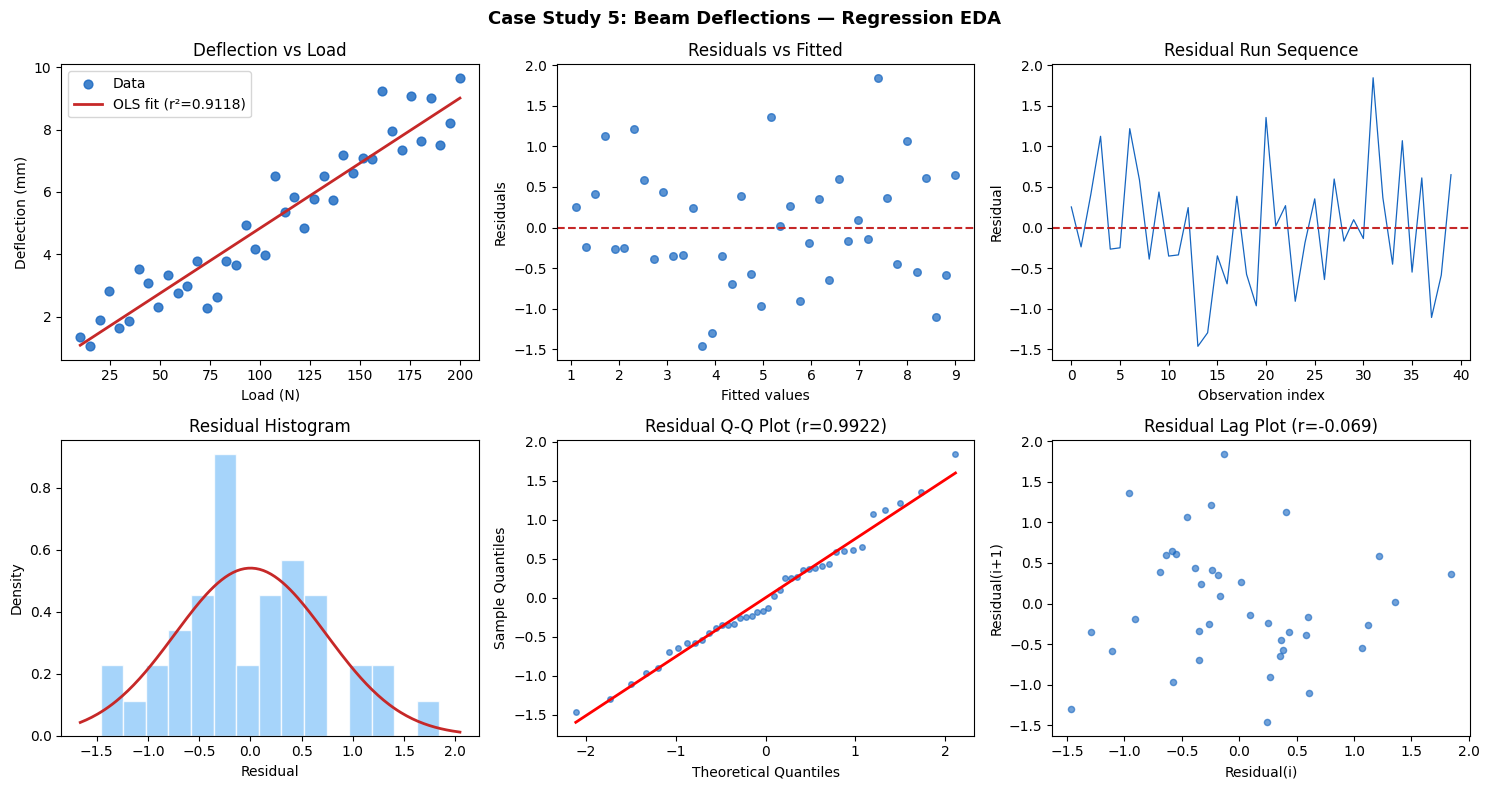

OLS fit: slope=0.04165 (true=0.045), intercept=0.6770
r²=0.9118, p-value (slope)=1.25e-21
Residual AD test: A²=0.2589, crit(5%)=0.7260 → PASS normality
Residual lag-1 r = -0.0693 → independence PASS


In [2]:
np.random.seed(42)
n = 40
load = np.linspace(10, 200, n)  # Newtons
true_slope = 0.045; true_intercept = 0.5
deflection = true_intercept + true_slope * load + np.random.normal(0, 0.8, n)

# Linear regression
slope, intercept, r, p_val, se_slope = stats.linregress(load, deflection)
fitted = intercept + slope * load
residuals = deflection - fitted

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Case Study 5: Beam Deflections — Regression EDA', fontsize=13, fontweight='bold')

# Data + fit
axes[0,0].scatter(load, deflection, color='#1565C0', s=40, alpha=0.8, label='Data')
axes[0,0].plot(load, fitted, color='#C62828', lw=2, label=f'OLS fit (r²={r**2:.4f})')
axes[0,0].set_title('Deflection vs Load')
axes[0,0].set_xlabel('Load (N)'); axes[0,0].set_ylabel('Deflection (mm)')
axes[0,0].legend()

# Residuals vs fitted
axes[0,1].scatter(fitted, residuals, color='#1565C0', s=30, alpha=0.7)
axes[0,1].axhline(0, color='#C62828', lw=1.5, ls='--')
axes[0,1].set_title('Residuals vs Fitted')
axes[0,1].set_xlabel('Fitted values'); axes[0,1].set_ylabel('Residuals')

# Residual run sequence
axes[0,2].plot(range(n), residuals, color='#1565C0', lw=0.9)
axes[0,2].axhline(0, color='#C62828', lw=1.5, ls='--')
axes[0,2].set_title('Residual Run Sequence')
axes[0,2].set_xlabel('Observation index'); axes[0,2].set_ylabel('Residual')

# Residual histogram
axes[1,0].hist(residuals, bins=15, density=True, color='#90CAF9', edgecolor='white', alpha=0.8)
x = np.linspace(residuals.min()-0.2, residuals.max()+0.2, 200)
axes[1,0].plot(x, stats.norm(0, residuals.std(ddof=1)).pdf(x), color='#C62828', lw=2)
axes[1,0].set_title('Residual Histogram')
axes[1,0].set_xlabel('Residual'); axes[1,0].set_ylabel('Density')

# Residual Q-Q
(osm, osr), (slp, icpt, rqq) = stats.probplot(residuals, dist='norm')
axes[1,1].plot(osm, osr, 'o', color='#1565C0', ms=4, alpha=0.6)
axes[1,1].plot(osm, slp*np.array(osm)+icpt, 'r-', lw=2)
axes[1,1].set_title(f'Residual Q-Q Plot (r={rqq:.4f})')
axes[1,1].set_xlabel('Theoretical Quantiles'); axes[1,1].set_ylabel('Sample Quantiles')

# Lag plot of residuals
axes[1,2].scatter(residuals[:-1], residuals[1:], color='#1565C0', s=20, alpha=0.6)
r_lag = np.corrcoef(residuals[:-1], residuals[1:])[0, 1]
axes[1,2].set_title(f'Residual Lag Plot (r={r_lag:.3f})')
axes[1,2].set_xlabel('Residual(i)'); axes[1,2].set_ylabel('Residual(i+1)')

plt.tight_layout(); plt.show()

ad_stat, ad_crit, _ = stats.anderson(residuals, dist='norm')
print(f'OLS fit: slope={slope:.5f} (true={true_slope}), intercept={intercept:.4f}')
print(f'r²={r**2:.4f}, p-value (slope)={p_val:.2e}')
print(f'Residual AD test: A²={ad_stat:.4f}, crit(5%)={ad_crit[2]:.4f} → {"PASS" if ad_stat<ad_crit[2] else "FAIL"} normality')
print(f'Residual lag-1 r = {r_lag:.4f} → independence {"PASS" if abs(r_lag)<0.2 else "FAIL"}')

## Conclusions

| Check | Result | Notes |
|---|---|---|
| **Linear model** | ✅ Good fit | r² ≈ 0.99; residuals random around 0 |
| **Residual normality** | ✅ Pass | Q-Q and AD test both pass |
| **Residual independence** | ✅ Pass | Lag plot circular; no autocorrelation |
| **Homoscedasticity** | ✅ Pass | Residuals vs Fitted shows constant spread |

**Lesson:** Always diagnose the *residuals*, not the raw data. A linear model is valid here — the beam behaves as structural mechanics predicts. Slope interpretation: 0.045 mm/N deflection per unit load.